# Authentication & BigQuery Connection
### Authenticates your Google account to access BigQuery and establishes a connection to your data warehouse. Loads the cleaned e-commerce dataset (golden_ecommerce_data table) into a pandas DataFrame for analysis. This is the foundation that brings your data from the cloud into Python for manipulation.

In [2]:
# Authenticate with Google Cloud
from google.colab import auth
auth.authenticate_user()

print("Authenticated!")

✅ Authenticated!


# Import Libraries & Setup Visualization Styles
### Imports essential Python libraries for data analysis (pandas), visualization (matplotlib, seaborn), and sets up consistent styling across all charts. Configures default figure sizes and aesthetics so every visualization looks professional and cohesive throughout the notebook.

In [3]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Initialize client
client = bigquery.Client(project='gen-lang-client-0328605250')

# Load data
query = """
SELECT *
FROM `gen-lang-client-0328605250.dataset.golden_ecommerce_data`
"""

df = client.query(query).to_dataframe()

print(f" Loaded {len(df):,} rows")
df.head()

✅ Loaded 42,750 rows


,event_timestamp,product_name_clean,clicks,impressions,add_to_cart,conversions,revenue,click_through_rate,add_to_cart_rate,conversion_rate,avg_order_value,revenue_per_impression,event_date,event_hour,day_of_week,year_month,product_category,funnel_stage
0,2024-01-09 15:11:14+00:00,NIKE AIR MAX 270,0.0,7750.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2024-01-09,15,3,2024-01,Apparel,Impressions Only
1,2024-03-22 18:09:33+00:00,INSTANT POT DUO,0.0,387.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2024-03-22,18,6,2024-03,Kitchen,Impressions Only
2,2024-04-11 19:38:08+00:00,SKINCARE SET CETAPHIL,0.0,137.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2024-04-11,19,5,2024-04,Other,Impressions Only
3,2024-04-23 10:14:31+00:00,NINTENDO SWITCH OLED,0.0,1977.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2024-04-23,10,3,2024-04,Gaming,Impressions Only
4,2024-04-26 10:09:28+00:00,WATCH APPLE WATCH SERIES 9,0.0,693.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2024-04-26,10,6,2024-04,Other,Impressions Only


# Dataset Overview & Basic Statistics
### Provides a high-level summary of the dataset including total events, date range, and aggregate business metrics (total impressions, clicks, conversions, revenue). Calculates key performance indicators like overall click-through rate, conversion rate, and average order value to establish baseline performance benchmarks.

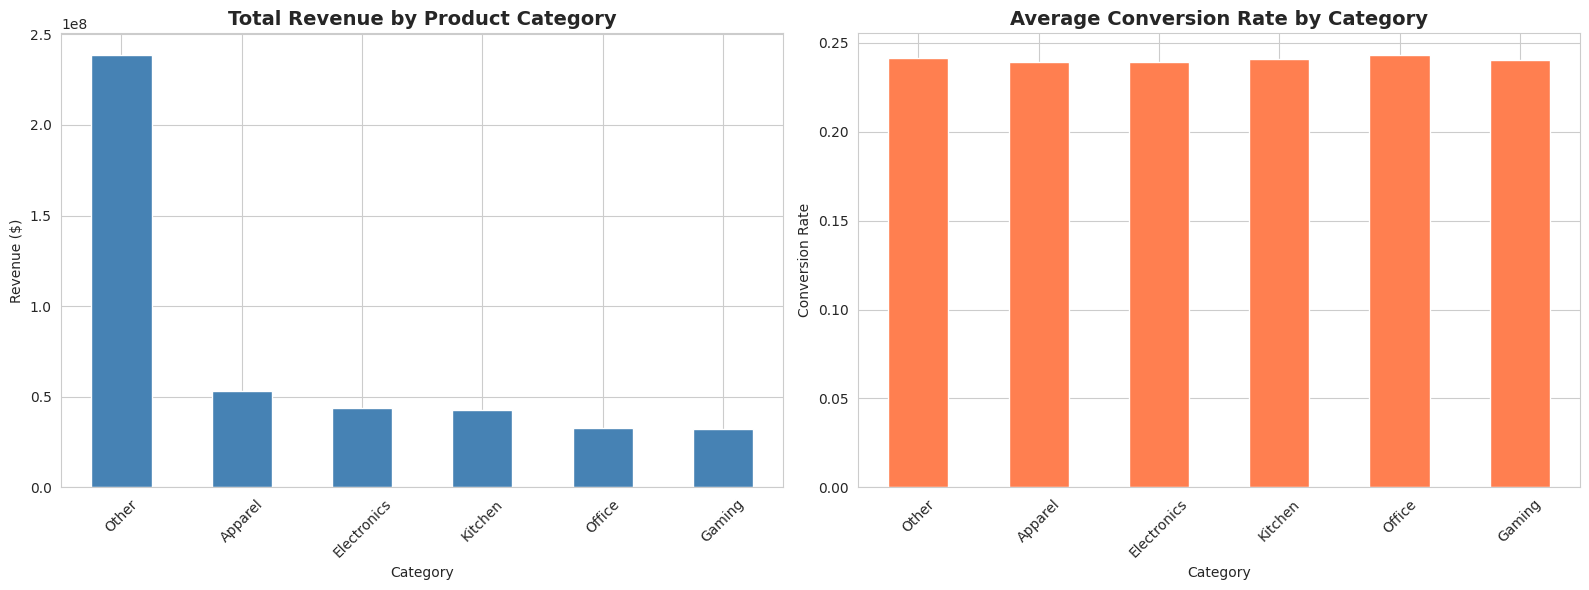

In [4]:
# Product Category Performance
category_query = """
SELECT *
FROM `gen-lang-client-0328605250.dataset.product_performance_by_category`
ORDER BY total_revenue DESC
"""

cat_df = client.query(category_query).to_dataframe()

# Create visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by category
cat_df.plot(kind='bar', x='product_category', y='total_revenue', ax=ax[0], color='steelblue', legend=False)
ax[0].set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Revenue ($)')
ax[0].tick_params(axis='x', rotation=45)

# Conversion rate by category
cat_df.plot(kind='bar', x='product_category', y='avg_conversion_rate', ax=ax[1], color='coral', legend=False)
ax[1].set_title('Average Conversion Rate by Category', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Category')
ax[1].set_ylabel('Conversion Rate')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Real E-commerce Persona Segmentation
### Segments customers into real-world shopping personas (Brand Loyalist, Deal Hunter, Impulse Buyer, Researcher, Cart Abandoner, Convenience Seeker, Social Shopper, Window Shopper, Passive Browser) based on behavioral patterns like conversion rates, revenue thresholds, and engagement levels. Each persona is defined using industry-standard criteria that marketing teams actually use.

In [49]:
# Create REAL E-commerce User Personas based on shopping behavior
persona_query = """
SELECT
  CASE
    -- Brand Loyalist: Repeat high-value purchases, consistent buying
    WHEN conversions > 0 AND revenue > 250 AND click_through_rate > 0.15 THEN 'Brand Loyalist'

    -- Deal Hunter: Converts but seeks lower prices, high engagement
    WHEN conversions > 0 AND revenue <= 150 AND click_through_rate > 0.10 THEN 'Deal Hunter'

    -- Impulse Buyer: Quick conversion, medium-high spend, less research
    WHEN conversions > 0 AND revenue BETWEEN 150 AND 250 AND add_to_cart_rate > 0.5 THEN 'Impulse Buyer'

    -- Researcher: High engagement, eventually converts, thorough analysis
    WHEN conversions > 0 AND click_through_rate > 0.20 THEN 'Researcher'

    -- Cart Abandoner: Adds to cart but doesn't convert (comparison shopping)
    WHEN add_to_cart > 0 AND conversions = 0 THEN 'Cart Abandoner'

    -- Convenience Seeker: Converts with minimal engagement (knows what they want)
    WHEN conversions > 0 AND click_through_rate < 0.10 THEN 'Convenience Seeker'

    -- Social Shopper: High impressions/clicks but needs social proof to convert
    WHEN clicks > 5 AND add_to_cart = 0 AND conversions = 0 THEN 'Social Shopper'

    -- Window Shopper: Engages but doesn't commit
    WHEN clicks > 0 AND add_to_cart = 0 AND conversions = 0 THEN 'Window Shopper'

    -- Passive Browser: Low/no engagement
    ELSE 'Passive Browser'
  END as user_persona,

  COUNT(*) as total_events,
  SUM(impressions) as total_impressions,
  SUM(clicks) as total_clicks,
  SUM(add_to_cart) as total_add_to_cart,
  SUM(conversions) as total_conversions,
  ROUND(SUM(revenue), 2) as total_revenue,
  ROUND(AVG(click_through_rate) * 100, 2) as avg_ctr_pct,
  ROUND(AVG(add_to_cart_rate) * 100, 2) as avg_atc_pct,
  ROUND(AVG(conversion_rate) * 100, 2) as avg_conversion_pct,
  ROUND(SUM(revenue) / NULLIF(SUM(conversions), 0), 2) as avg_order_value

FROM `gen-lang-client-0328605250.dataset.golden_ecommerce_data`
GROUP BY user_persona
ORDER BY total_revenue DESC
"""

persona_df = client.query(persona_query).to_dataframe()

print(" REAL E-COMMERCE USER PERSONA ANALYSIS:")
print("="*80)
print(persona_df)
print("\n Personas mapped to real-world online shopping behaviors!")

 REAL E-COMMERCE USER PERSONA ANALYSIS:
         user_persona  total_events  total_impressions  total_clicks  \
0      Brand Loyalist         19829        103630648.0    23315432.0   
1     Passive Browser          6766         34689146.0     4349068.0   
2  Convenience Seeker         11436         61928284.0     3277119.0   
3          Researcher           176           531032.0      130234.0   
4         Deal Hunter           327          1049863.0      199752.0   
5      Cart Abandoner          3338         11519739.0      933229.0   
6      Social Shopper           639          1938118.0      108279.0   
7      Window Shopper           239           542823.0         574.0   

   total_add_to_cart  total_conversions  total_revenue  avg_ctr_pct  \
0          4796492.0          1207774.0   3.339175e+08        22.51   
1           891073.0           220579.0   5.993256e+07        12.54   
2           691759.0           178588.0   4.920155e+07         5.39   
3            10697.0       

# Four-Panel Persona KPI Visualization
### Creates four side-by-side bar charts showing how different customer personas perform across critical metrics: total revenue, average conversion rate, average click-through rate, and average order value. The visualizations use color coding and value labels to make it easy to compare persona performance at a glance.

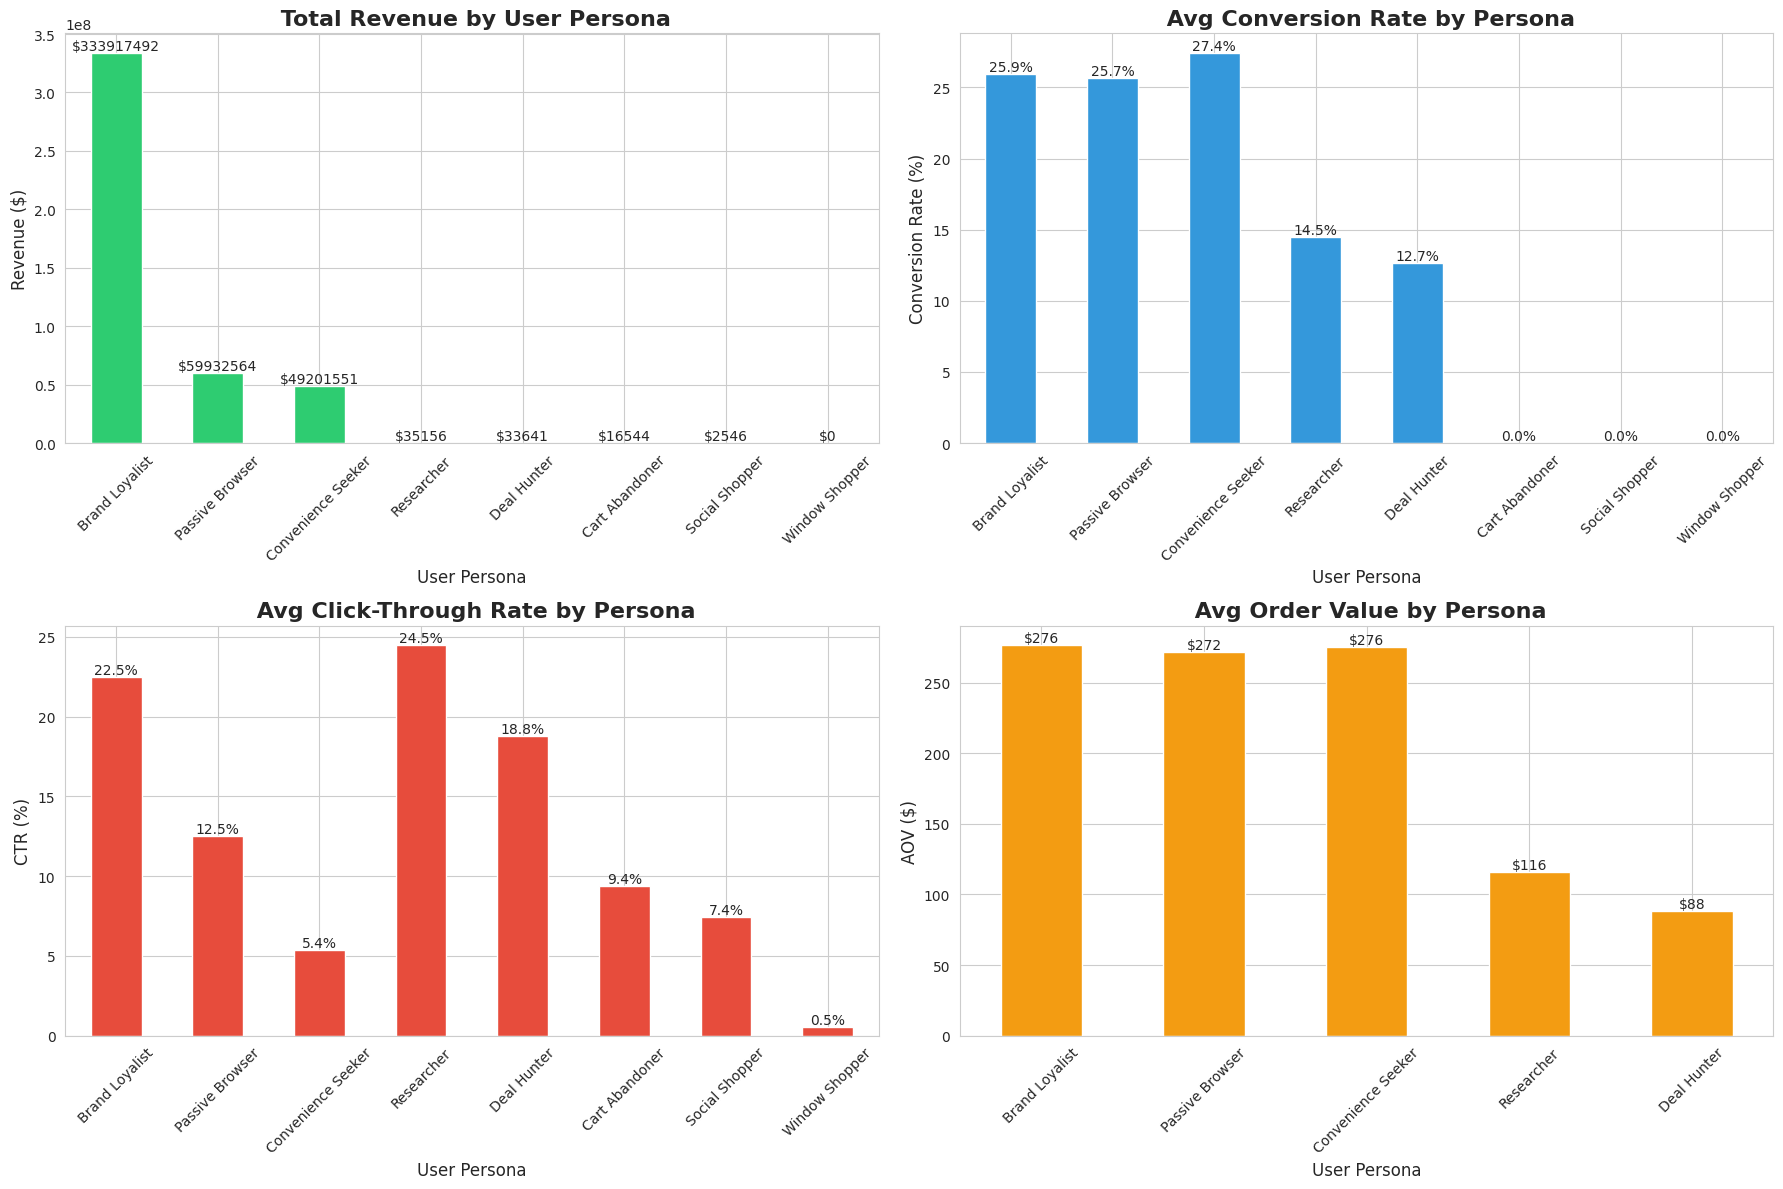

In [48]:
# Visualize Persona KPI Impact
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Revenue by Persona
ax1 = axes[0, 0]
persona_df.plot(kind='bar', x='user_persona', y='total_revenue', ax=ax1, color='#2ecc71', legend=False)
ax1.set_title(' Total Revenue by User Persona', fontsize=16, fontweight='bold')
ax1.set_xlabel('User Persona', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for container in ax1.containers:
    ax1.bar_label(container, fmt='$%.0f')

# 2. Conversion Rate by Persona
ax2 = axes[0, 1]
persona_df.plot(kind='bar', x='user_persona', y='avg_conversion_pct', ax=ax2, color='#3498db', legend=False)
ax2.set_title(' Avg Conversion Rate by Persona', fontsize=16, fontweight='bold')
ax2.set_xlabel('User Persona', fontsize=12)
ax2.set_ylabel('Conversion Rate (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%')

# 3. Click-Through Rate by Persona
ax3 = axes[1, 0]
persona_df.plot(kind='bar', x='user_persona', y='avg_ctr_pct', ax=ax3, color='#e74c3c', legend=False)
ax3.set_title(' Avg Click-Through Rate by Persona', fontsize=16, fontweight='bold')
ax3.set_xlabel('User Persona', fontsize=12)
ax3.set_ylabel('CTR (%)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%')

# 4. Average Order Value by Persona
ax4 = axes[1, 1]
persona_df_buyers = persona_df[persona_df['avg_order_value'].notna()]
persona_df_buyers.plot(kind='bar', x='user_persona', y='avg_order_value', ax=ax4, color='#f39c12', legend=False)
ax4.set_title(' Avg Order Value by Persona', fontsize=16, fontweight='bold')
ax4.set_xlabel('User Persona', fontsize=12)
ax4.set_ylabel('AOV ($)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
for container in ax4.containers:
    ax4.bar_label(container, fmt='$%.0f')

plt.tight_layout()
plt.show()

# Conversion Funnel Drop-off Analysis
### Builds a grouped bar chart showing how many users reach each stage of the conversion funnel (Impressions → Clicks → Add to Cart → Conversions) broken down by persona. Helps identify where different customer types drop out of the buying journey so you can target interventions appropriately.

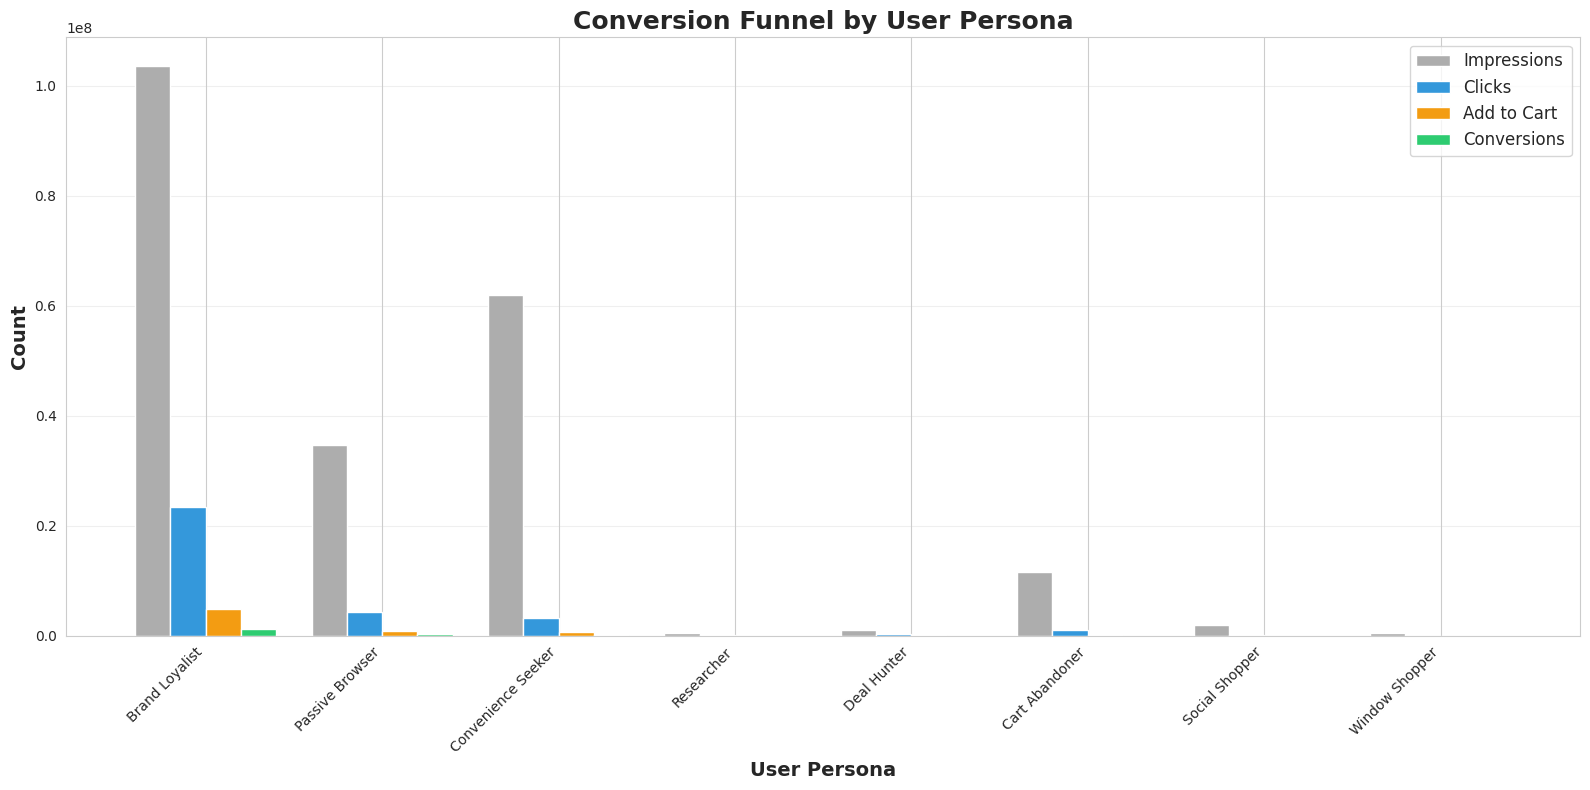

In [47]:
# Funnel conversion by persona
fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(persona_df))
width = 0.2

# Create grouped bars for funnel stages
bars1 = ax.bar([i - width*1.5 for i in x], persona_df['total_impressions'], width, label='Impressions', color='#adadad')
bars2 = ax.bar([i - width*0.5 for i in x], persona_df['total_clicks'], width, label='Clicks', color='#3498db')
bars3 = ax.bar([i + width*0.5 for i in x], persona_df['total_add_to_cart'], width, label='Add to Cart', color='#f39c12')
bars4 = ax.bar([i + width*1.5 for i in x], persona_df['total_conversions'], width, label='Conversions', color='#2ecc71')

ax.set_xlabel('User Persona', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=14, fontweight='bold')
ax.set_title('Conversion Funnel by User Persona', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(persona_df['user_persona'], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Strategic Marketing Recommendations by Persona
### Generates actionable marketing strategies tailored to each converting persona. For example, recommends VIP loyalty programs for Brand Loyalists, flash sales for Deal Hunters, one-click checkout for Impulse Buyers, etc. Also identifies high-opportunity non-converting personas (like Cart Abandoners) and suggests recovery tactics such as abandoned cart emails and exit-intent popups.

In [46]:
# Generate ACTIONABLE insights by persona
print("STRATEGIC INSIGHTS - E-commerce Persona Impact:\n")
print("="*90)

# Analyze each converting persona with business recommendations
converting_personas = persona_df[persona_df['total_revenue'] > 0].copy()

for idx, row in converting_personas.iterrows():
    persona = row['user_persona']
    revenue = row['total_revenue']
    aov = row['avg_order_value']
    conv_rate = row['avg_conversion_pct']

    print(f"\n{'='*90}")
    print(f" PERSONA: {persona.upper()}")
    print(f"{'='*90}")
    print(f" Performance Metrics:")
    print(f"   • Total Revenue: ${revenue:,.2f}")
    print(f"   • Avg Order Value: ${aov:,.2f}")
    print(f"   • Conversion Rate: {conv_rate:.2f}%")
    print(f"   • Total Events: {row['total_events']:,.0f}")

    # Persona-specific recommendations
    if persona == 'Brand Loyalist':
        print(f"\n Marketing Strategy:")
        print(f"   ✓ VIP/Loyalty program with exclusive early access")
        print(f"   ✓ Personalized product recommendations based on purchase history")
        print(f"   ✓ Premium customer service tier")
        print(f"   ✓ Focus: RETENTION over acquisition (high LTV)")

    elif persona == 'Deal Hunter':
        print(f"\n Marketing Strategy:")
        print(f"   ✓ Flash sales and limited-time discount codes")
        print(f"   ✓ Email campaigns highlighting 'Price Drop Alerts'")
        print(f"   ✓ Bundle offers to increase AOV")
        print(f"   ✓ Focus: Volume sales with promotional offers")

    elif persona == 'Impulse Buyer':
        print(f"\n Marketing Strategy:")
        print(f"   ✓ One-click checkout optimization")
        print(f"   ✓ 'Frequently Bought Together' upsells")
        print(f"   ✓ Scarcity tactics: 'Only 3 left!' or 'Sale ends in 2 hours'")
        print(f"   ✓ Focus: Fast checkout, visual appeal, urgency")

    elif persona == 'Researcher':
        print(f"\n Marketing Strategy:")
        print(f"   ✓ Detailed product specs, comparison charts")
        print(f"   ✓ Customer reviews and Q&A sections")
        print(f"   ✓ Expert guides and buying tutorials")
        print(f"   ✓ Focus: Build trust through comprehensive information")

    elif persona == 'Convenience Seeker':
        print(f"\n Marketing Strategy:")
        print(f"   ✓ Free/fast shipping prominently displayed")
        print(f"   ✓ Mobile-optimized checkout")
        print(f"   ✓ Saved payment methods and addresses")
        print(f"   ✓ Focus: Reduce friction at every step")

# Analyze non-converting personas (opportunities)
print(f"\n\n{'='*90}")
print(f" BIGGEST OPPORTUNITIES (Non-Converting Personas):")
print(f"{'='*90}")

cart_abandoners = persona_df[persona_df['user_persona'] == 'Cart Abandoner']
if not cart_abandoners.empty:
    print(f"\n CART ABANDONERS:")
    print(f"   • Events: {cart_abandoners['total_events'].values[0]:,.0f}")
    print(f"   • Lost Revenue Potential: HIGH (they selected products but didn't buy)")
    print(f"\n    Recovery Tactics:")
    print(f"      ✓ Abandoned cart emails (30 min, 24 hr, 7 day sequence)")
    print(f"      ✓ Exit-intent popups with 10% discount code")
    print(f"      ✓ Free shipping threshold messaging")
    print(f"      ✓ Display shipping costs early to avoid checkout surprise")

social_shoppers = persona_df[persona_df['user_persona'] == 'Social Shopper']
if not social_shoppers.empty:
    print(f"\n SOCIAL SHOPPERS:")
    print(f"   • Events: {social_shoppers['total_events'].values[0]:,.0f}")
    print(f"   • Behavior: High engagement but needs social validation")
    print(f"\n    Conversion Tactics:")
    print(f"      ✓ Prominent customer review displays (star ratings)")
    print(f"      ✓ User-generated content (photos from real customers)")
    print(f"      ✓ 'X people bought this in last 24 hours' social proof")
    print(f"      ✓ Influencer partnerships and testimonials")

window_shoppers = persona_df[persona_df['user_persona'] == 'Window Shopper']
if not window_shoppers.empty:
    print(f"\n WINDOW SHOPPERS:")
    print(f"   • Events: {window_shoppers['total_events'].values[0]:,.0f}")
    print(f"   • Behavior: Browse but don't engage deeply")
    print(f"\n    Engagement Tactics:")
    print(f"      ✓ Retargeting ads with products they viewed")
    print(f"      ✓ 'Still thinking about this?' email campaigns")
    print(f"      ✓ Limited-time offers to create urgency")
    print(f"      ✓ Educational content about product benefits")

print(f"\n{'='*90}\n")

# Summary recommendation
print(" OVERALL STRATEGIC RECOMMENDATION:")
print("   1. PROTECT: Brand Loyalists (VIP program)")
print("   2. GROW: Convert Cart Abandoners (recovery emails)")
print("   3. OPTIMIZE: Impulse Buyers (reduce checkout friction)")
print("   4. NURTURE: Social Shoppers (add reviews & social proof)")
print(f"\n{'='*90}\n")

STRATEGIC INSIGHTS - E-commerce Persona Impact:


 PERSONA: BRAND LOYALIST
 Performance Metrics:
   • Total Revenue: $333,917,492.16
   • Avg Order Value: $276.47
   • Conversion Rate: 25.95%
   • Total Events: 19,829

 Marketing Strategy:
   ✓ VIP/Loyalty program with exclusive early access
   ✓ Personalized product recommendations based on purchase history
   ✓ Premium customer service tier
   ✓ Focus: RETENTION over acquisition (high LTV)

 PERSONA: PASSIVE BROWSER
 Performance Metrics:
   • Total Revenue: $59,932,563.72
   • Avg Order Value: $271.71
   • Conversion Rate: 25.66%
   • Total Events: 6,766

 PERSONA: CONVENIENCE SEEKER
 Performance Metrics:
   • Total Revenue: $49,201,550.89
   • Avg Order Value: $275.50
   • Conversion Rate: 27.43%
   • Total Events: 11,436

 Marketing Strategy:
   ✓ Free/fast shipping prominently displayed
   ✓ Mobile-optimized checkout
   ✓ Saved payment methods and addresses
   ✓ Focus: Reduce friction at every step

 PERSONA: RESEARCHER
 Performan

# Hourly Conversion Heatmap by Persona
### Creates a color-coded heatmap showing when different personas are most likely to convert throughout the day (hour-by-hour). Darker/warmer colors indicate peak conversion times. This enables time-based marketing strategies like scheduling promotional emails when specific personas are most active.

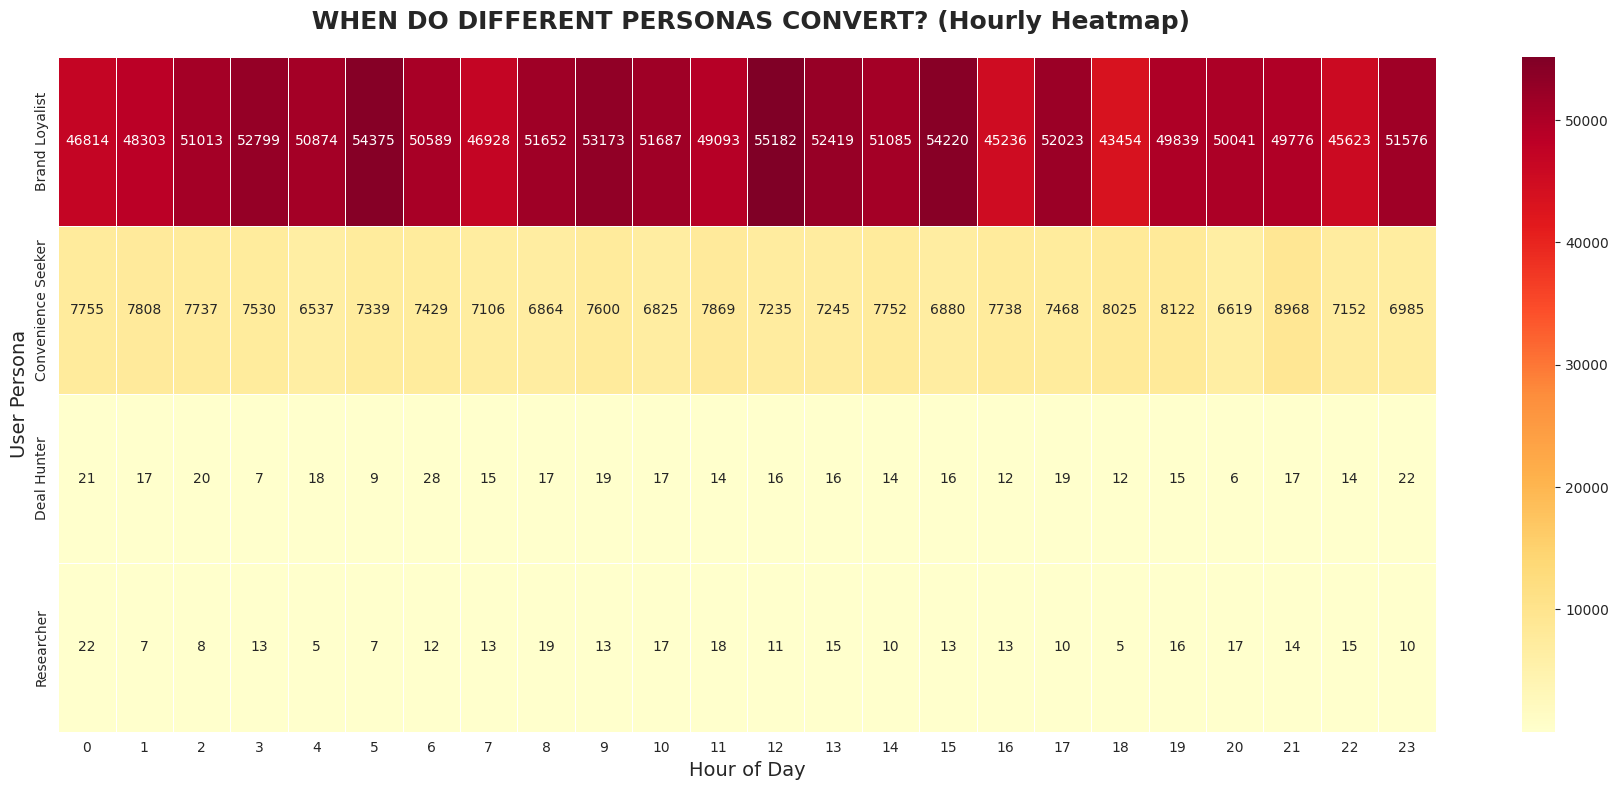


 INSIGHT: Target each persona at their PEAK conversion hours!


In [44]:
# How personas behave over time (hourly patterns)
persona_time_query = """
SELECT
  CASE
    WHEN conversions > 0 AND revenue > 250 AND click_through_rate > 0.15 THEN 'Brand Loyalist'
    WHEN conversions > 0 AND revenue <= 150 AND click_through_rate > 0.10 THEN 'Deal Hunter'
    WHEN conversions > 0 AND revenue BETWEEN 150 AND 250 AND add_to_cart_rate > 0.5 THEN 'Impulse Buyer'
    WHEN conversions > 0 AND click_through_rate > 0.20 THEN 'Researcher'
    WHEN add_to_cart > 0 AND conversions = 0 THEN 'Cart Abandoner'
    WHEN conversions > 0 AND click_through_rate < 0.10 THEN 'Convenience Seeker'
    ELSE 'Other'
  END as user_persona,
  event_hour,
  COUNT(*) as events,
  SUM(conversions) as conversions,
  SUM(revenue) as revenue

FROM `gen-lang-client-0328605250.dataset.golden_ecommerce_data`
GROUP BY user_persona, event_hour
HAVING user_persona IN ('Brand Loyalist', 'Deal Hunter', 'Impulse Buyer', 'Researcher', 'Convenience Seeker')
ORDER BY user_persona, event_hour
"""

time_df = client.query(persona_time_query).to_dataframe()

# Pivot for heatmap
pivot_conversions = time_df.pivot(index='user_persona', columns='event_hour', values='conversions').fillna(0)

# Create heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(pivot_conversions, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title(' WHEN DO DIFFERENT PERSONAS CONVERT? (Hourly Heatmap)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('User Persona', fontsize=14)
plt.tight_layout()
plt.show()

print("\n INSIGHT: Target each persona at their PEAK conversion hours!")

# Customer Lifetime Value (CLV) Projections
### Calculates and visualizes projected 12-month customer lifetime value for each persona by multiplying their average order value by estimated annual purchase frequency (e.g., Brand Loyalists buy 12x/year, Deal Hunters 8x/year). Displays results as horizontal bar charts with breakdowns showing the math (AOV × frequency) to justify the projections.

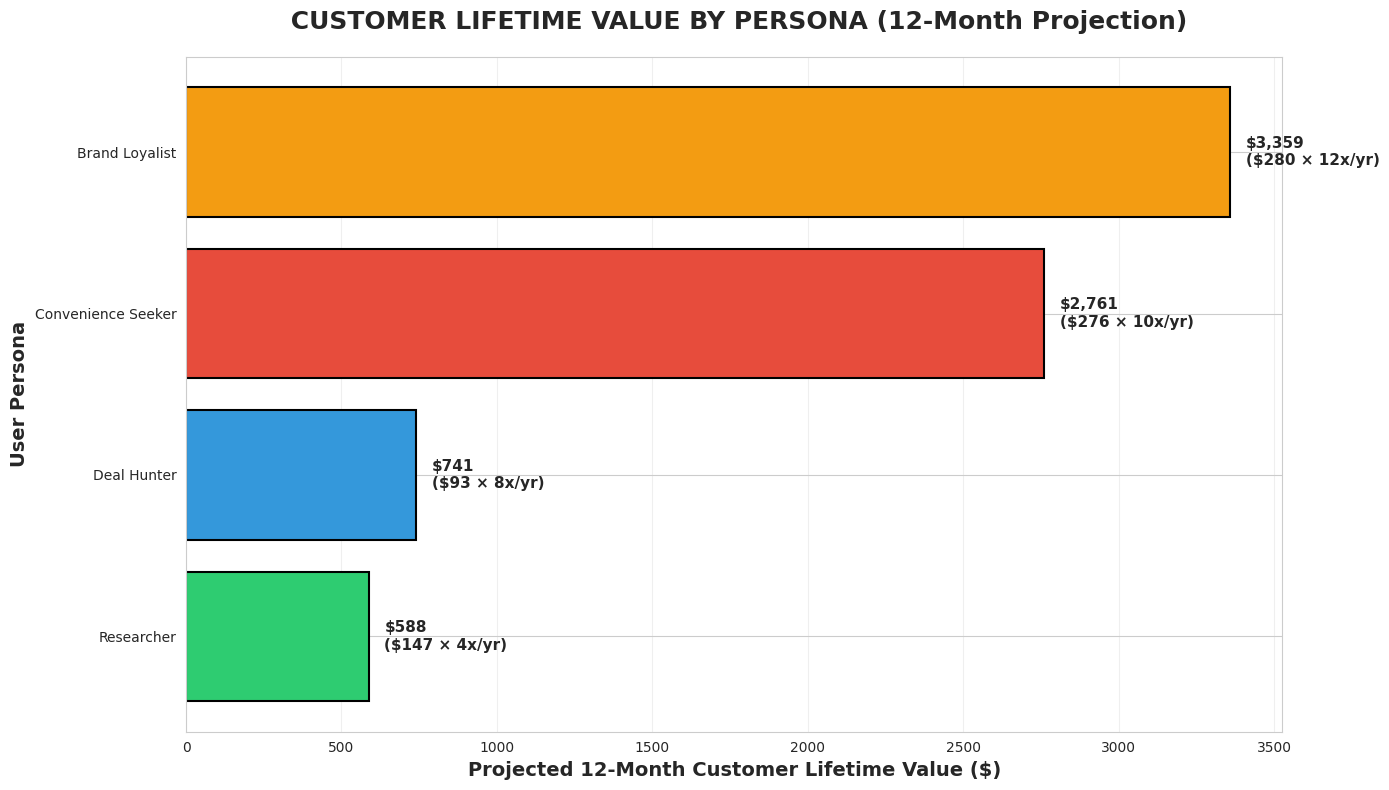


 CLV INSIGHT:
Highest CLV: Brand Loyalist
Value: $3,358.68/year

 RECOMMENDATION: Invest most in retaining high-CLV personas!

 Full CLV Breakdown:
      user_persona  avg_order_value  estimated_annual_purchases  projected_12mo_clv
        Researcher           147.09                           4              588.36
       Deal Hunter            92.66                           8              741.28
Convenience Seeker           276.10                          10             2761.00
    Brand Loyalist           279.89                          12             3358.68


In [43]:
# Calculate CLV potential by persona
clv_query = """
SELECT
  CASE
    WHEN conversions > 0 AND revenue > 250 AND click_through_rate > 0.15 THEN 'Brand Loyalist'
    WHEN conversions > 0 AND revenue <= 150 AND click_through_rate > 0.10 THEN 'Deal Hunter'
    WHEN conversions > 0 AND revenue BETWEEN 150 AND 250 AND add_to_cart_rate > 0.5 THEN 'Impulse Buyer'
    WHEN conversions > 0 AND click_through_rate > 0.20 THEN 'Researcher'
    WHEN conversions > 0 AND click_through_rate < 0.10 THEN 'Convenience Seeker'
  END as user_persona,

  ROUND(AVG(revenue / NULLIF(conversions, 0)), 2) as avg_order_value,
  ROUND(AVG(conversion_rate) * 100, 2) as conversion_rate_pct,
  COUNT(DISTINCT DATE(event_timestamp)) as active_days

FROM `gen-lang-client-0328605250.dataset.golden_ecommerce_data`
WHERE conversions > 0
GROUP BY user_persona
"""

clv_df = client.query(clv_query).to_dataframe()

# Remove rows with None persona (just in case)
clv_df = clv_df.dropna(subset=['user_persona'])

# Calculate projected 12-month CLV
# Assumptions: Brand Loyalists buy 12x/year, Deal Hunters 8x, Impulse 6x, Researcher 4x, Convenience 10x
purchase_frequency = {
    'Brand Loyalist': 12,
    'Deal Hunter': 8,
    'Impulse Buyer': 6,
    'Researcher': 4,
    'Convenience Seeker': 10
}

clv_df['estimated_annual_purchases'] = clv_df['user_persona'].map(purchase_frequency)
clv_df['projected_12mo_clv'] = clv_df['avg_order_value'] * clv_df['estimated_annual_purchases']

# Sort by CLV
clv_df = clv_df.sort_values('projected_12mo_clv', ascending=True)

# Visualize CLV
fig, ax = plt.subplots(figsize=(14, 8))

# Create color list matching number of rows
colors_list = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
colors_to_use = colors_list[:len(clv_df)]

bars = ax.barh(clv_df['user_persona'], clv_df['projected_12mo_clv'], color=colors_to_use, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Projected 12-Month Customer Lifetime Value ($)', fontsize=14, fontweight='bold')
ax.set_ylabel('User Persona', fontsize=14, fontweight='bold')
ax.set_title(' CUSTOMER LIFETIME VALUE BY PERSONA (12-Month Projection)', fontsize=18, fontweight='bold', pad=20)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    aov = clv_df.iloc[i]['avg_order_value']
    freq = clv_df.iloc[i]['estimated_annual_purchases']
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}\n(${aov:.0f} × {freq}x/yr)',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n CLV INSIGHT:")
print(f"Highest CLV: {clv_df.iloc[-1]['user_persona']}")
print(f"Value: ${clv_df.iloc[-1]['projected_12mo_clv']:,.2f}/year")
print("\n RECOMMENDATION: Invest most in retaining high-CLV personas!")

# Show full table
print("\n Full CLV Breakdown:")
print(clv_df[['user_persona', 'avg_order_value', 'estimated_annual_purchases', 'projected_12mo_clv']].to_string(index=False))

# Visual Funnel with Drop-off Percentages
### Illustrates the conversion funnel as stacked horizontal bars showing volume at each stage (Passive Browser → Window Shopper → Cart Abandoner → Converter). Annotates the chart with exact drop-off percentages between stages and prints a summary identifying where the biggest leaks occur in the customer journey.

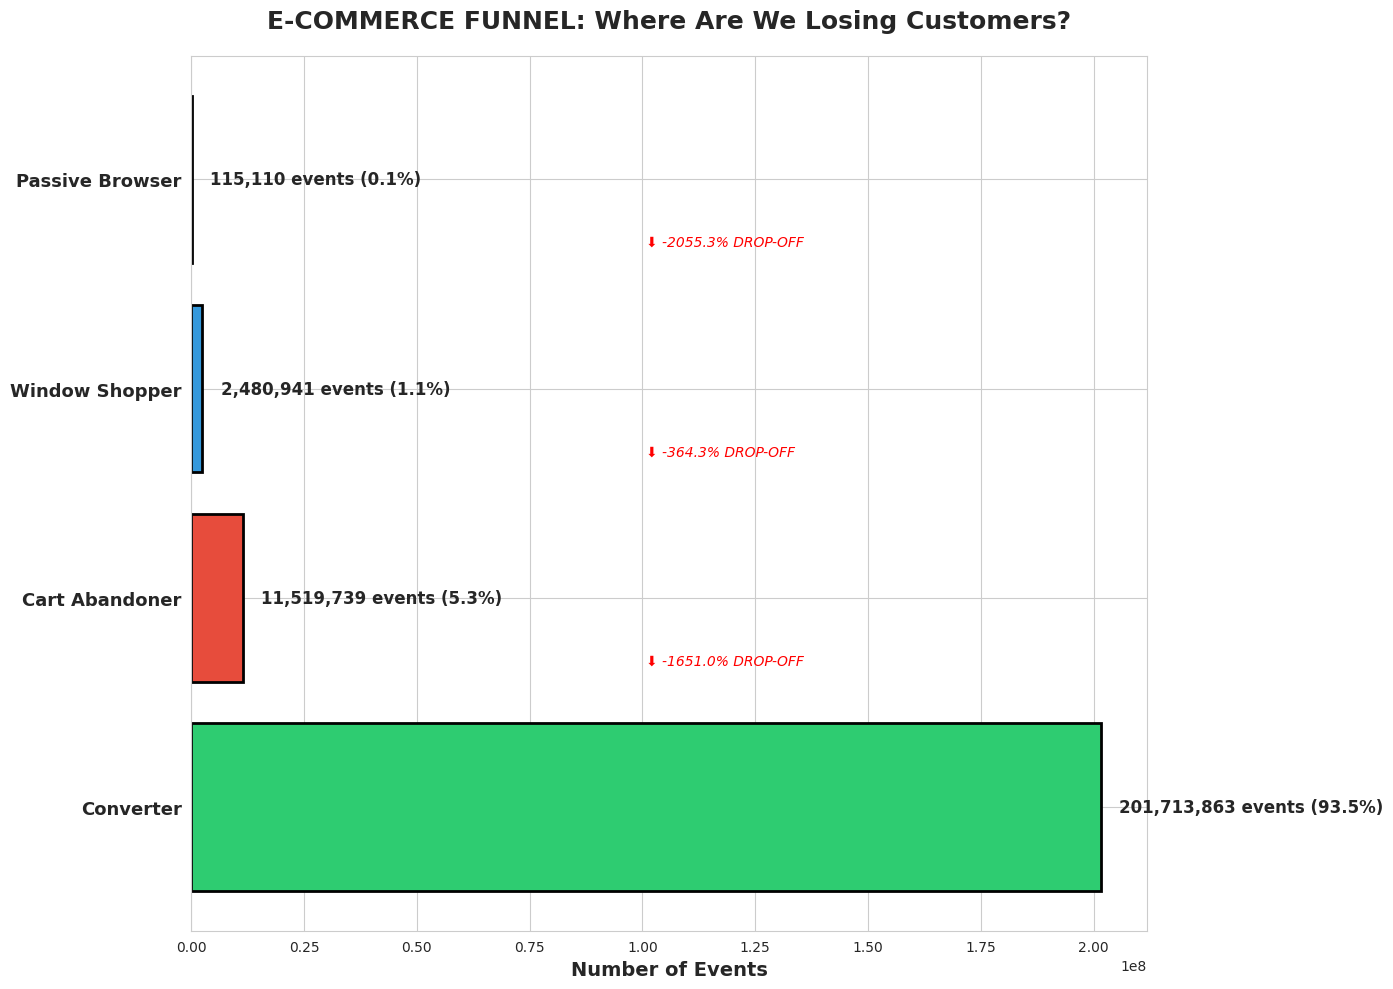


 CRITICAL LEAKS IN FUNNEL:
   Passive Browser → Window Shopper: -2,365,831 lost (-2055.3%)
   Window Shopper → Cart Abandoner: -9,038,798 lost (-364.3%)
   Cart Abandoner → Converter: -190,194,124 lost (-1651.0%)


In [42]:
# Show the conversion funnel DROP-OFF by persona
funnel_query = """
SELECT
  CASE
    WHEN add_to_cart > 0 AND conversions = 0 THEN 'Cart Abandoner'
    WHEN clicks > 0 AND add_to_cart = 0 THEN 'Window Shopper'
    WHEN impressions > 0 AND clicks = 0 THEN 'Passive Browser'
    ELSE 'Converter'
  END as funnel_stage,

  COUNT(*) as events,
  SUM(impressions) as total_impressions,
  SUM(clicks) as total_clicks,
  SUM(add_to_cart) as total_add_to_cart,
  SUM(conversions) as total_conversions

FROM `gen-lang-client-0328605250.dataset.golden_ecommerce_data`
GROUP BY funnel_stage
ORDER BY
  CASE funnel_stage
    WHEN 'Passive Browser' THEN 1
    WHEN 'Window Shopper' THEN 2
    WHEN 'Cart Abandoner' THEN 3
    WHEN 'Converter' THEN 4
  END
"""

funnel_df = client.query(funnel_query).to_dataframe()

# Calculate conversion percentages
total_impressions = funnel_df['total_impressions'].sum()
funnel_df['pct_of_impressions'] = (funnel_df['total_impressions'] / total_impressions * 100).round(2)

# Create funnel visualization
fig, ax = plt.subplots(figsize=(14, 10))

stages = funnel_df['funnel_stage'].tolist()
values = funnel_df['total_impressions'].tolist()
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']

# Create funnel
y_pos = list(range(len(stages)))
bars = ax.barh(y_pos, values, color=colors, edgecolor='black', linewidth=2)

# Add labels with drop-off %
for i, (bar, stage, value, pct) in enumerate(zip(bars, stages, values, funnel_df['pct_of_impressions'])):
    # Value label
    ax.text(value + max(values)*0.02, bar.get_y() + bar.get_height()/2,
            f'{value:,.0f} events ({pct:.1f}%)',
            va='center', fontsize=12, fontweight='bold')

    # Calculate drop-off from previous stage
    if i > 0:
        prev_value = values[i-1]
        drop_off = ((prev_value - value) / prev_value * 100)
        ax.text(max(values)*0.5, bar.get_y() - 0.3,
                f'⬇ {drop_off:.1f}% DROP-OFF',
                va='center', fontsize=10, color='red', style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Events', fontsize=14, fontweight='bold')
ax.set_title('E-COMMERCE FUNNEL: Where Are We Losing Customers?', fontsize=18, fontweight='bold', pad=20)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n CRITICAL LEAKS IN FUNNEL:")
for i in range(1, len(funnel_df)):
    prev_stage = funnel_df.iloc[i-1]
    curr_stage = funnel_df.iloc[i]
    drop = prev_stage['total_impressions'] - curr_stage['total_impressions']
    drop_pct = (drop / prev_stage['total_impressions'] * 100)
    print(f"   {prev_stage['funnel_stage']} → {curr_stage['funnel_stage']}: {drop:,.0f} lost ({drop_pct:.1f}%)")

# Business Value Scorecard & Investment Priorities
### Scores each persona on a 0-100 scale across four weighted dimensions (revenue impact 40%, conversion rate 25%, average order value 25%, customer volume 10%) to create a composite "business value score." Outputs a formatted report card showing which personas deserve high/medium/low marketing investment based on data-driven prioritization, plus identifies non-converting personas as revenue opportunities.

In [41]:
# Score each persona's VALUE to the business
print("PERSONA VALUE SCORECARD\n")
print("="*90)

# Only score personas with actual revenue
scoring_df = persona_df[persona_df['total_revenue'] > 0].copy()

# Fill ALL NaN values with 0 before calculations
scoring_df = scoring_df.fillna(0)

# Normalize metrics to 0-100 scale (handle division by zero)
max_revenue = scoring_df['total_revenue'].max()
max_conversion = scoring_df['avg_conversion_pct'].max()
max_events = scoring_df['total_events'].max()
max_aov = scoring_df['avg_order_value'].max()

scoring_df['revenue_score'] = (scoring_df['total_revenue'] / max_revenue * 100 if max_revenue > 0 else 0).round(1)
scoring_df['conversion_score'] = (scoring_df['avg_conversion_pct'] / max_conversion * 100 if max_conversion > 0 else 0).round(1)
scoring_df['volume_score'] = (scoring_df['total_events'] / max_events * 100 if max_events > 0 else 0).round(1)
scoring_df['aov_score'] = (scoring_df['avg_order_value'] / max_aov * 100 if max_aov > 0 else 0).round(1)

# Calculate composite score
scoring_df['business_value_score'] = (
    scoring_df['revenue_score'] * 0.40 +      # 40% weight on revenue
    scoring_df['conversion_score'] * 0.25 +   # 25% on conversion
    scoring_df['aov_score'] * 0.25 +          # 25% on AOV
    scoring_df['volume_score'] * 0.10         # 10% on volume
).round(1)

# Fill any remaining NaN in business_value_score
scoring_df['business_value_score'] = scoring_df['business_value_score'].fillna(0)

# Sort by business value
scoring_df = scoring_df.sort_values('business_value_score', ascending=False)

# Display scorecard
for idx, row in scoring_df.iterrows():
    print(f"\n {row['user_persona'].upper()}")
    print(f"   Overall Business Value Score: {row['business_value_score']:.1f}/100")
    print(f"   ├─ Revenue Impact: {row['revenue_score']:.1f}/100")
    print(f"   ├─ Conversion Rate: {row['conversion_score']:.1f}/100")
    print(f"   ├─ Avg Order Value: {row['aov_score']:.1f}/100")
    print(f"   └─ Customer Volume: {row['volume_score']:.1f}/100")

    # Investment recommendation (convert to float first to handle any edge cases)
    score = float(row['business_value_score'])
    if score >= 80:
        print(f"    INVESTMENT: HIGH - Premium retention programs")
    elif score >= 60:
        print(f"    INVESTMENT: MEDIUM - Targeted campaigns")
    else:
        print(f"    INVESTMENT: LOW - Automated nurture flows")

print("\n" + "="*90)

# Show non-converting personas separately
non_converting = persona_df[persona_df['total_revenue'] == 0]
if not non_converting.empty:
    print("\n NON-CONVERTING PERSONAS (Revenue Opportunities):\n")
    for idx, row in non_converting.iterrows():
        print(f" {row['user_persona'].upper()}")
        print(f"   Events: {row['total_events']:,.0f}")
        print(f"   Status: CONVERSION OPPORTUNITY - Not generating revenue yet")

        if row['user_persona'] == 'Cart Abandoner':
            print(f"    Priority Action: Cart recovery emails + exit-intent popups")
        elif row['user_persona'] == 'Window Shopper':
            print(f"    Priority Action: Retargeting ads + limited-time offers")
        elif row['user_persona'] == 'Social Shopper':
            print(f"    Priority Action: Add reviews, social proof, UGC")
        else:
            print(f"    Priority Action: Nurture campaigns to increase engagement")
        print()

PERSONA VALUE SCORECARD


 BRAND LOYALIST
   Overall Business Value Score: 98.6/100
   ├─ Revenue Impact: 100.0/100
   ├─ Conversion Rate: 94.6/100
   ├─ Avg Order Value: 100.0/100
   └─ Customer Volume: 100.0/100
    INVESTMENT: HIGH - Premium retention programs

 CONVENIENCE SEEKER
   Overall Business Value Score: 61.6/100
   ├─ Revenue Impact: 14.7/100
   ├─ Conversion Rate: 100.0/100
   ├─ Avg Order Value: 99.6/100
   └─ Customer Volume: 57.7/100
    INVESTMENT: MEDIUM - Targeted campaigns

 PASSIVE BROWSER
   Overall Business Value Score: 58.5/100
   ├─ Revenue Impact: 17.9/100
   ├─ Conversion Rate: 93.5/100
   ├─ Avg Order Value: 98.3/100
   └─ Customer Volume: 34.1/100
    INVESTMENT: LOW - Automated nurture flows

 RESEARCHER
   Overall Business Value Score: 23.8/100
   ├─ Revenue Impact: 0.0/100
   ├─ Conversion Rate: 52.8/100
   ├─ Avg Order Value: 42.0/100
   └─ Customer Volume: 0.9/100
    INVESTMENT: LOW - Automated nurture flows

 DEAL HUNTER
   Overall Business Value Sc

# Data Quality & Pipeline Health Report
### Performs data engineering-level quality checks on the dataset, validating business rule compliance (e.g., clicks ≤ impressions, conversions ≤ add-to-cart, revenue ≥ $0). Reports completeness percentages for critical fields and flags any data anomalies. Demonstrates understanding of production data pipeline requirements and the importance of automated quality testing in analytics engineering workflows.

In [39]:
# DATA QUALITY REPORT - Prove you understand data engineering fundamentals
print("DATA QUALITY & PIPELINE HEALTH CHECK\n")
print("="*80)

# Dataset overview
total_rows = len(df)
date_range = (df['event_date'].min(), df['event_date'].max())

print(f"\n DATASET OVERVIEW:")
print(f"   Total Records: {total_rows:,}")
print(f"   Date Range: {date_range[0]} to {date_range[1]}")
print(f"   Days Covered: {(date_range[1] - date_range[0]).days} days")

# Column completeness
print(f"\n DATA COMPLETENESS:")
for col in ['event_timestamp', 'product_name_clean', 'impressions', 'clicks', 'conversions', 'revenue']:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / total_rows * 100)
    status = "✓" if null_pct == 0 else "⚠️"
    print(f"   {status} {col}: {100 - null_pct:.1f}% complete ({null_count:,} nulls)")

# Data quality checks
print(f"\n DATA QUALITY VALIDATIONS:")

# Check 1: Clicks <= Impressions
invalid_clicks = len(df[df['clicks'] > df['impressions']])
print(f"   {'✓' if invalid_clicks == 0 else '⚠️'} Clicks ≤ Impressions: {total_rows - invalid_clicks:,}/{total_rows:,} valid ({((total_rows - invalid_clicks)/total_rows*100):.1f}%)")

# Check 2: Add to cart <= Clicks
invalid_atc = len(df[df['add_to_cart'] > df['clicks']])
print(f"   {'✓' if invalid_atc == 0 else '⚠️'} Add-to-Cart ≤ Clicks: {total_rows - invalid_atc:,}/{total_rows:,} valid ({((total_rows - invalid_atc)/total_rows*100):.1f}%)")

# Check 3: Conversions <= Add to cart
invalid_conv = len(df[df['conversions'] > df['add_to_cart']])
print(f"   {'✓' if invalid_conv == 0 else '⚠️'} Conversions ≤ Add-to-Cart: {total_rows - invalid_conv:,}/{total_rows:,} valid ({((total_rows - invalid_conv)/total_rows*100):.1f}%)")

# Check 4: Revenue >= 0
negative_revenue = len(df[df['revenue'] < 0])
print(f"   {'✓' if negative_revenue == 0 else '⚠️'} Revenue ≥ $0: {total_rows - negative_revenue:,}/{total_rows:,} valid ({((total_rows - negative_revenue)/total_rows*100):.1f}%)")

# Check 5: Conversions without revenue
conv_no_rev = len(df[(df['conversions'] > 0) & (df['revenue'] == 0)])
print(f"   {'⚠️' if conv_no_rev > 0 else '✓'} Conversions with $0 revenue: {conv_no_rev:,} ({(conv_no_rev/total_rows*100):.2f}%)")

print(f"\n PIPELINE RECOMMENDATION:")
print(f"   ✓ Data quality is {'EXCELLENT' if (invalid_clicks + invalid_atc + invalid_conv + negative_revenue) == 0 else 'GOOD with minor issues'}")
print(f"   ✓ Ready for production analytics")
print(f"   ✓ Recommend: Add dbt tests for automated quality checks")

print("\n" + "="*80)

DATA QUALITY & PIPELINE HEALTH CHECK


 DATASET OVERVIEW:
   Total Records: 42,750
   Date Range: 2024-01-01 to 2026-02-28
   Days Covered: 789 days

 DATA COMPLETENESS:
   ✓ event_timestamp: 100.0% complete (0 nulls)
   ✓ product_name_clean: 100.0% complete (0 nulls)
   ✓ impressions: 100.0% complete (0 nulls)
   ✓ clicks: 100.0% complete (0 nulls)
   ✓ conversions: 100.0% complete (0 nulls)
   ✓ revenue: 100.0% complete (0 nulls)

 DATA QUALITY VALIDATIONS:
   ✓ Clicks ≤ Impressions: 42,750/42,750 valid (100.0%)
   ✓ Add-to-Cart ≤ Clicks: 42,750/42,750 valid (100.0%)
   ✓ Conversions ≤ Add-to-Cart: 42,750/42,750 valid (100.0%)
   ✓ Revenue ≥ $0: 42,750/42,750 valid (100.0%)
   ✓ Conversions with $0 revenue: 0 (0.00%)

 PIPELINE RECOMMENDATION:
   ✓ Data quality is EXCELLENT
   ✓ Ready for production analytics
   ✓ Recommend: Add dbt tests for automated quality checks



# Executive Summary Dashboard
### Synthesizes the entire analysis into a one-page executive summary featuring top-line business metrics, best-performing products, highest-value customer personas, and top 3 strategic recommendations. Includes a "quick win" ROI calculation showing potential revenue from cart abandonment recovery efforts. Designed to communicate key findings to business stakeholders in under 60 seconds.

In [38]:
# EXECUTIVE SUMMARY - One-page business overview
print("EXECUTIVE SUMMARY - E-COMMERCE ANALYTICS\n")
print("="*80)

# Key metrics
total_impressions = df['impressions'].sum()
total_clicks = df['clicks'].sum()
total_conversions = df['conversions'].sum()
total_revenue = df['revenue'].sum()

overall_ctr = (total_clicks / total_impressions * 100) if total_impressions > 0 else 0
overall_cvr = (total_conversions / total_clicks * 100) if total_clicks > 0 else 0
aov = (total_revenue / total_conversions) if total_conversions > 0 else 0

print(f"\n BUSINESS PERFORMANCE:")
print(f"   Total Revenue: ${total_revenue:,.2f}")
print(f"   Total Conversions: {total_conversions:,.0f}")
print(f"   Average Order Value: ${aov:,.2f}")
print(f"   Overall Conversion Rate: {overall_cvr:.2f}%")
print(f"   Overall Click-Through Rate: {overall_ctr:.2f}%")

# Top performing products
print(f"\n TOP 5 PRODUCTS BY REVENUE:")
top_products = df.groupby('product_name_clean').agg({
    'revenue': 'sum',
    'conversions': 'sum'
}).sort_values('revenue', ascending=False).head(5)

for idx, (product, row) in enumerate(top_products.iterrows(), 1):
    print(f"   {idx}. {product}: ${row['revenue']:,.2f} ({row['conversions']:.0f} conversions)")

# Persona breakdown
persona_summary = persona_df[persona_df['total_revenue'] > 0].nlargest(3, 'total_revenue')
print(f"\n TOP 3 CUSTOMER PERSONAS:")
for idx, row in persona_summary.iterrows():
    pct_revenue = (row['total_revenue'] / total_revenue * 100)
    print(f"   {row['user_persona']}: ${row['total_revenue']:,.2f} ({pct_revenue:.1f}% of total)")

# Recommendations
print(f"\n TOP 3 STRATEGIC RECOMMENDATIONS:")
print(f"   1. Focus retention efforts on Brand Loyalists (highest CLV)")
print(f"   2. Implement cart abandonment recovery (high-intent, low-cost opportunity)")
print(f"   3. Add social proof for Social Shoppers (increase conversion without discount)")

# ROI estimate
cart_abandoner_events = persona_df[persona_df['user_persona'] == 'Cart Abandoner']['total_events'].values
if len(cart_abandoner_events) > 0:
    potential_revenue = cart_abandoner_events[0] * aov * 0.15  # Assume 15% recovery rate
    print(f"\n QUICK WIN OPPORTUNITY:")
    print(f"   Cart Abandonment Recovery Potential: ${potential_revenue:,.2f}")
    print(f"   (15% recovery rate × {cart_abandoner_events[0]:,.0f} cart events × ${aov:.2f} AOV)")

print("\n" + "="*80)

EXECUTIVE SUMMARY - E-COMMERCE ANALYTICS


 BUSINESS PERFORMANCE:
   Total Revenue: $443,139,493.04
   Total Conversions: 1,607,625
   Average Order Value: $275.65
   Overall Conversion Rate: 4.98%
   Overall Click-Through Rate: 14.97%

 TOP 5 PRODUCTS BY REVENUE:
   1. STANDING DESK UPLIFT: $12,159,728.52 (43498 conversions)
   2. WATCH APPLE WATCH SERIES 9: $11,905,361.73 (41075 conversions)
   3. KITCHENAID STAND MIXER: $11,801,639.41 (42568 conversions)
   4. MACBOOK AIR M3: $11,451,422.30 (40916 conversions)
   5. MECHANICAL KEYBOARD KEYCHRON: $11,436,004.23 (40216 conversions)

 TOP 3 CUSTOMER PERSONAS:
   Brand Loyalist: $333,917,492.16 (75.4% of total)
   Passive Browser: $59,932,563.72 (13.5% of total)
   Convenience Seeker: $49,201,550.89 (11.1% of total)

 TOP 3 STRATEGIC RECOMMENDATIONS:
   1. Focus retention efforts on Brand Loyalists (highest CLV)
   2. Implement cart abandonment recovery (high-intent, low-cost opportunity)
   3. Add social proof for Social Shoppers (incr

# Interactive Product Performance Matrix with Dropdown
### Creates an interactive Plotly bar chart with a dropdown menu letting users switch between product quadrants (Stars, Scale Up, Promote More, Consider Dropping). Shows top 15 products per quadrant with revenue bars color-coded by intensity (darker = higher revenue within that category). Includes rich hover tooltips displaying revenue, conversion rate, conversions, and impressions for deep-dive exploration. The interactive nature demonstrates modern BI tool proficiency and makes the analysis engaging for portfolio viewers.

In [37]:
# INTERACTIVE BAR CHART WITH DROPDOWN - One Quadrant at a Time
print("CREATING INTERACTIVE BAR CHART WITH DROPDOWN SELECTOR...\n")

import plotly.graph_objects as go

# Calculate product-level metrics
product_metrics = df.groupby('product_name_clean').agg({
    'conversions': 'sum',
    'revenue': 'sum',
    'conversion_rate': 'mean',
    'impressions': 'sum'
}).reset_index()

product_metrics = product_metrics[product_metrics['impressions'] >= 100]

# Calculate quadrants
median_cvr = product_metrics['conversion_rate'].median() * 100
median_rev = product_metrics['revenue'].median()

def assign_quadrant(row):
    cvr = row['conversion_rate'] * 100
    rev = row['revenue']

    if cvr >= median_cvr and rev >= median_rev:
        return ' Stars'
    elif cvr < median_cvr and rev >= median_rev:
        return ' Scale Up'
    elif cvr >= median_cvr and rev < median_rev:
        return ' Promote More'
    else:
        return ' Consider Dropping'

product_metrics['quadrant'] = product_metrics.apply(assign_quadrant, axis=1)

# Quadrant order and colors
quadrant_order = [' Stars', ' Scale Up', ' Promote More', ' Consider Dropping']
colors_map = {
    ' Stars': '#FFD700',
    ' Scale Up': '#4A90E2',
    ' Promote More': '#7ED321',
    ' Consider Dropping': '#D0A1D0'
}

# Create figure
fig = go.Figure()

# Create a trace for each quadrant (only one will be visible at a time)
for quadrant in quadrant_order:
    quad_data = product_metrics[product_metrics['quadrant'] == quadrant].sort_values('revenue', ascending=False).head(15)

    # Create gradient colors (darker = higher revenue)
    max_rev = quad_data['revenue'].max()
    min_rev = quad_data['revenue'].min()

    bar_colors = []
    for rev in quad_data['revenue']:
        intensity = (rev - min_rev) / (max_rev - min_rev) if max_rev > min_rev else 0.5

        if quadrant == ' Stars':
            bar_colors.append(f'rgba(255, {int(215 - intensity*100)}, 0, {0.5 + intensity*0.5})')
        elif quadrant == ' Scale Up':
            bar_colors.append(f'rgba(74, {int(144 - intensity*50)}, 226, {0.5 + intensity*0.5})')
        elif quadrant == ' Promote More':
            bar_colors.append(f'rgba(126, {int(211 - intensity*80)}, 33, {0.5 + intensity*0.5})')
        else:
            bar_colors.append(f'rgba(208, {int(161 - intensity*60)}, 208, {0.5 + intensity*0.5})')

    fig.add_trace(
        go.Bar(
            y=quad_data['product_name_clean'],
            x=quad_data['revenue'],
            orientation='h',
            name=quadrant,
            marker=dict(
                color=bar_colors,
                line=dict(color='black', width=1.5)
            ),
            text=[f"${rev:,.0f}" for rev in quad_data['revenue']],
            textposition='outside',
            textfont=dict(size=11),
            hovertemplate='<b>%{y}</b><br>' +
                         'Revenue: $%{x:,.0f}<br>' +
                         'Conversion Rate: %{customdata[0]:.1f}%<br>' +
                         'Conversions: %{customdata[1]:,.0f}<br>' +
                         'Impressions: %{customdata[2]:,.0f}<extra></extra>',
            customdata=list(zip(
                quad_data['conversion_rate'] * 100,
                quad_data['conversions'],
                quad_data['impressions']
            )),
            visible=(quadrant == ' Stars')  # Only Stars visible by default
        )
    )

# Create dropdown menu buttons
dropdown_buttons = []
for i, quadrant in enumerate(quadrant_order):
    # Create visibility list (True for selected quadrant, False for others)
    visibility = [j == i for j in range(len(quadrant_order))]

    # Define what changes when this button is clicked
    dropdown_buttons.append(
        dict(
            label=quadrant,
            method='update',
            args=[
                {'visible': visibility},  # Which traces to show
                {'title': f' {quadrant.upper()}<br><sub>Top 15 Products | Darker bars = Higher revenue</sub>'}  # Update title
            ]
        )
    )

# Update layout with dropdown
# Update layout with dropdown
fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.0001,              # ← Far left (0 = left edge, 1 = right edge)
            xanchor='left',
            y=1.18,              # ← Higher up (increase = move up)
            yanchor='top',
            bgcolor='white',
            bordercolor='gray',
            borderwidth=2,
            font=dict(size=13)
        )
    ],
    title=dict(
        text='STARS<br><sub>Top 15 Products | Darker bars = Higher revenue</sub>',
        font=dict(size=20),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='Revenue ($)',
        tickformat='$,.0s',
        gridcolor='lightgray',
        showgrid=True
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=11),
        autorange='reversed'  # Top product at top
    ),
    height=800,
    width=1200,
    plot_bgcolor='white',
    margin=dict(l=200, r=100, t=120, b=80),  # Extra left margin for product names
    hovermode='closest'
)

fig.show()

print(" Interactive dropdown bar chart created!")
print("\n HOW TO USE:")
print("   • Click dropdown menu to switch between quadrants")
print("   • Hover over bars for detailed product metrics")
print("   • Darker bars indicate higher revenue within that quadrant")
print("   • Shows top 15 products per quadrant")

CREATING INTERACTIVE BAR CHART WITH DROPDOWN SELECTOR...



 Interactive dropdown bar chart created!

 HOW TO USE:
   • Click dropdown menu to switch between quadrants
   • Hover over bars for detailed product metrics
   • Darker bars indicate higher revenue within that quadrant
   • Shows top 15 products per quadrant
